In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [2]:
f = "../osm/012_measures/run/eplusout.sql"
cb = read_sql(f,alias=True)
data_cb = cb.data
data_cb

variable_name,Ti_BANO,Ti_CIRCULACION,Ti_COMERCIO,Ti_ESCALERA,To,Ti_RECAMARAPA,Ti_RECAMARAPB,Ti_SALA
date,,,,,,,,
2006-01-01 00:10:00,15.875336,18.341211,20.391096,16.468183,8.566667,15.028296,15.060757,17.498457
2006-01-01 00:20:00,15.834611,18.265357,20.303718,16.404457,8.333333,14.926259,14.997618,17.392559
2006-01-01 00:30:00,15.792917,18.191310,20.215694,16.341321,8.100000,14.822109,14.932578,17.286770
2006-01-01 00:40:00,15.749197,18.119315,20.125153,16.277539,7.866667,14.720761,14.863191,17.179488
2006-01-01 00:50:00,15.702778,18.047369,20.034640,16.213034,7.633333,14.621861,14.788735,17.071413
...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,15.600781,17.975080,20.117233,16.322218,10.366667,15.115093,14.895479,17.493418
2006-12-31 23:30:00,15.575942,17.924359,20.040253,16.280834,10.300000,15.041948,14.855624,17.410702
2006-12-31 23:40:00,15.549530,17.872016,19.963115,16.237939,10.233333,14.967537,14.814164,17.326870


(np.float64(13269.0), np.float64(13300.0))

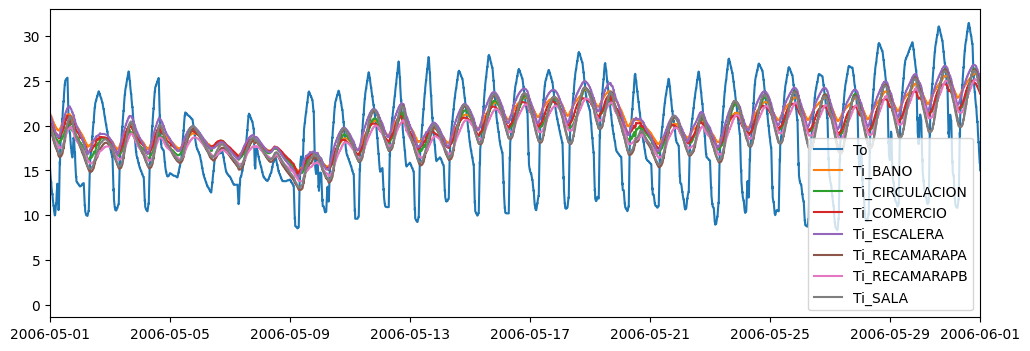

In [3]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(data_cb.To, label="To")
ax.plot(data_cb.Ti_BANO, label="Ti_BANO")
ax.plot(data_cb.Ti_CIRCULACION, label="Ti_CIRCULACION")
ax.plot(data_cb.Ti_COMERCIO, label="Ti_COMERCIO")
ax.plot(data_cb.Ti_ESCALERA, label="Ti_ESCALERA")
ax.plot(data_cb.Ti_RECAMARAPA, label="Ti_RECAMARAPA")
ax.plot(data_cb.Ti_RECAMARAPB, label="Ti_RECAMARAPB")
ax.plot(data_cb.Ti_SALA, label="Ti_SALA")

ax.legend()

ax.set_xlim(f1,f2)

In [4]:
a = {"bano":1.7*2.2}

In [5]:
areas = {"BANO":1.7*2.2, "CIRCULACION":3.7, "COMERCIO":3.4*3+1.2*0.7, "ESCALERA":2.2*2.7, "RECAMARAPA":2.6*4.4+1.7*2.2, "RECAMARAPB":2.6*4.4, "SALA":4.4*3.7}

In [6]:
pesos = {nombre: area / sum(areas.values()) for nombre, area in areas.items()}
pesos

{'BANO': 0.05555555555555555,
 'CIRCULACION': 0.054961378490790254,
 'COMERCIO': 0.1639928698752228,
 'ESCALERA': 0.08823529411764706,
 'RECAMARAPA': 0.22549019607843138,
 'RECAMARAPB': 0.16993464052287582,
 'SALA': 0.24183006535947713}

In [7]:
temps = data_cb.copy()
temps["Ti"] = sum(temps[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,Ti_BANO,Ti_CIRCULACION,Ti_COMERCIO,Ti_ESCALERA,To,Ti_RECAMARAPA,Ti_RECAMARAPB,Ti_SALA,Ti
date,,,,,,,,,
2006-01-01 00:10:00,15.875336,18.341211,20.391096,16.468183,8.566667,15.028296,15.060757,17.498457,16.866821
2006-01-01 00:20:00,15.834611,18.265357,20.303718,16.404457,8.333333,14.926259,14.997618,17.392559,16.781090
2006-01-01 00:30:00,15.792917,18.191310,20.215694,16.341321,8.100000,14.822109,14.932578,17.286770,16.694578
2006-01-01 00:40:00,15.749197,18.119315,20.125153,16.277539,7.866667,14.720761,14.863191,17.179488,16.607128
2006-01-01 00:50:00,15.702778,18.047369,20.034640,16.213034,7.633333,14.621861,14.788735,17.071413,16.518970
...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,15.600781,17.975080,20.117233,16.322218,10.366667,15.115093,14.895479,17.493418,16.763921
2006-12-31 23:30:00,15.575942,17.924359,20.040253,16.280834,10.300000,15.041948,14.855624,17.410702,16.700208
2006-12-31 23:40:00,15.549530,17.872016,19.963115,16.237939,10.233333,14.967537,14.814164,17.326870,16.635332


(np.float64(13269.0), np.float64(13300.0))

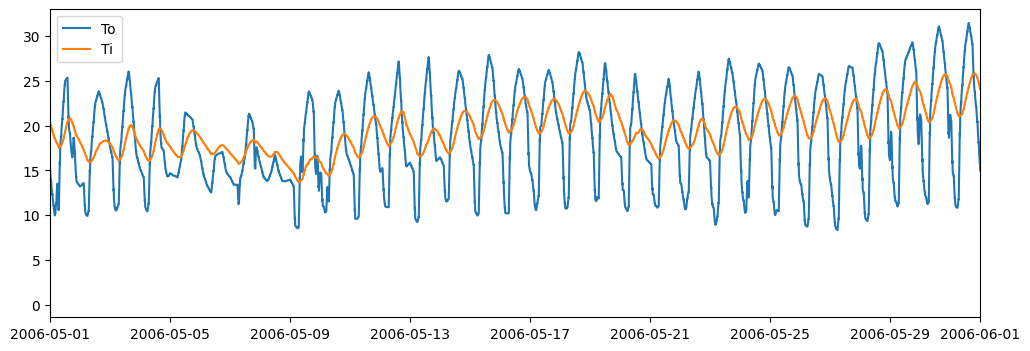

In [8]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.To, label="To")
ax.plot(temps.Ti, label="Ti")

ax.legend()

ax.set_xlim(f1,f2)